## 1. **Introduction to SVC**

A **Support Vector Classifier (SVC)** is a **supervised machine learning model** used primarily for **classification problems**. Its goal is to **find the best decision boundary (hyperplane)** that separates classes in the feature space.

Think of it as drawing a line (in 2D) or a plane (in higher dimensions) that **separates different categories of data points** with the **maximum possible margin**.


## 2. **Mathematical Formulation**

Suppose we have training data:

$$
{(x_1, y_1), (x_2, y_2), ..., (x_n, y_n)}, \quad y_i \in {-1, +1}
$$

where:

* $(x_i)$ = feature vector
* $(y_i)$ = class label

The SVC tries to find a hyperplane:

$$
w \cdot x + b = 0
$$

Where:

* (w) = weight vector (normal to the hyperplane)
* (b) = bias term
* (x) = feature vector

**Decision rule**:

$$
f(x) = \text{sign}(w \cdot x + b)
$$

## 3. **Maximizing the Margin**

The **margin** is the distance between the hyperplane and the closest points of any class. SVC aims to **maximize this margin** to ensure better generalization.

Distance from a point (x_i) to the hyperplane:

$$
\text{Distance} = \frac{|w \cdot x_i + b|}{|w|}
$$

**Optimization problem (hard-margin SVC):**

$$
\text{Minimize } \frac{1}{2} |w|^2
$$

Subject to:

$$
y_i (w \cdot x_i + b) \geq 1 \quad \forall i
$$

* This ensures all points are correctly classified and at least 1 unit away from the hyperplane.


## 4. **Soft Margin for Non-linearly Separable Data**

Real-world data isn’t always perfectly separable. We introduce **slack variables** $(\xi_i \ge 0)$ to allow some misclassifications:

$$
y_i (w \cdot x_i + b) \geq 1 - \xi_i
$$

**Objective function (soft-margin SVC):**

$$
\text{Minimize } \frac{1}{2}|w|^2 + C \sum_{i=1}^{n} \xi_i
$$

Where:

* (C) = penalty parameter controlling trade-off between **margin size** and **misclassification**.
* Large (C) → fewer misclassifications, smaller margin
* Small (C) → larger margin, more tolerance to misclassification


## 5. **Kernel Trick (Non-linear Decision Boundaries)**

For complex datasets, SVC can map data to a **higher-dimensional space** using a **kernel function**:

* **Linear kernel**: $ (K(x_i, x_j) = x_i \cdot x_j)$
* **Polynomial kernel**: $(K(x_i, x_j) = (x_i \cdot x_j + 1)^d)$
* **RBF (Gaussian) kernel**: $(K(x_i, x_j) = \exp(-\gamma |x_i - x_j|^2))$
* **Sigmoid kernel**: $(K(x_i, x_j) = \tanh(\alpha x_i \cdot x_j + r))$

**Key idea**: The kernel allows SVC to **solve non-linear problems without explicitly computing higher dimensions**.


## 6. **Support Vectors**

* **Support vectors** are the **data points closest to the hyperplane**.
* They are critical because **only they define the position of the hyperplane**.
* Points farther away don’t affect the model.


## 7. **Prediction**

Once trained, the SVC predicts using:

$$
f(x) = \text{sign} \left( \sum_{i \in SV} \alpha_i y_i K(x_i, x) + b \right)
$$

Where:

* $(SV)$ = support vectors
* $(\alpha_i)$ = Lagrange multipliers obtained from optimization
* $(K(x_i, x))$ = kernel function


## 8. **Hyperparameters**

* **C** → regularization strength
* **kernel** → linear, polynomial, rbf, sigmoid
* **gamma** → influence of single training example (for rbf/polynomial kernels)
* **degree** → degree of polynomial kernel


**Importing Libraries**

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn datasets
from sklearn.datasets import load_breast_cancer

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Pipeline
from sklearn.pipeline import Pipeline

# Model
from sklearn.svm import SVC

# Model tuning
from sklearn.model_selection import GridSearchCV

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Explainability
import shap

# Model saving
import joblib

**Load dataset**

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

In [3]:
df = pd.concat([X, y], axis=1)
df.rename(columns={0: "target"}, inplace=True)

In [4]:
print("Dataset shape:", df.shape)

Dataset shape: (569, 31)


In [5]:
display(df.head())

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [6]:
print(data.DESCR[:1000])

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

**Exploratory Data Analysis (EDA)**

In [7]:
print("Data types:\n", df.dtypes)

Data types:
 mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst concave points       float64
worst s

In [8]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [9]:
print("\nStatistical summary:\n", df.describe())


Statistical summary:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000           

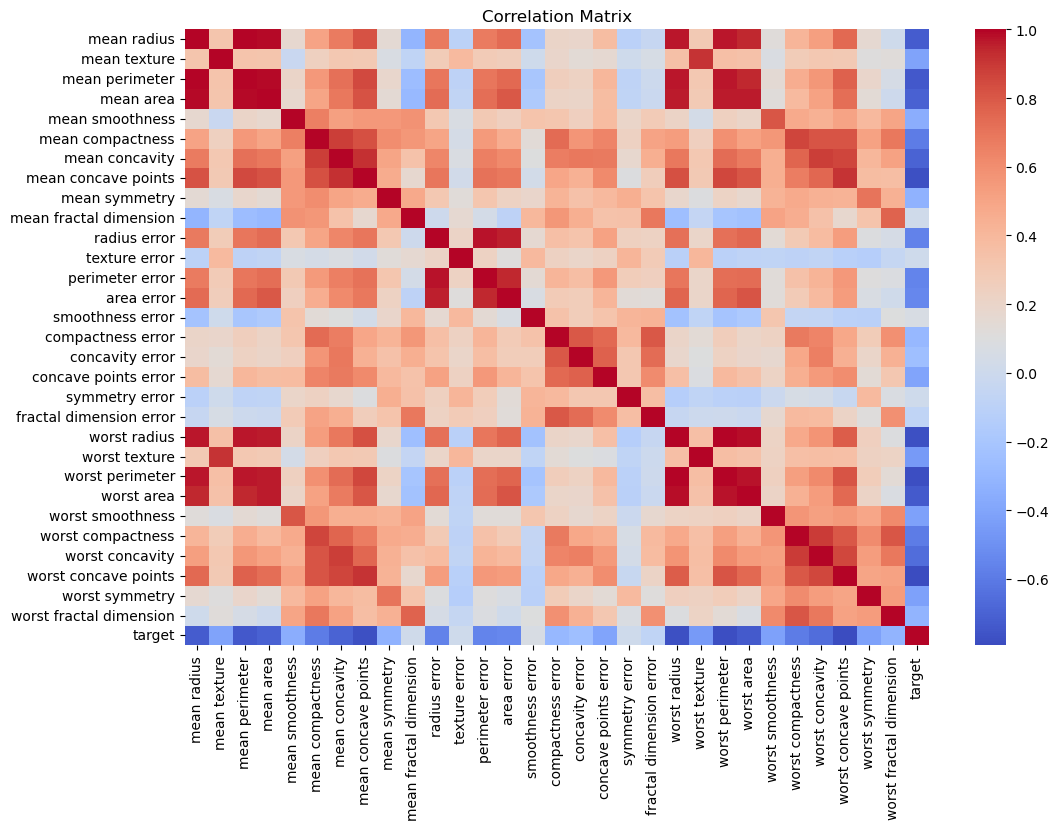

In [10]:
# Correlation Matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

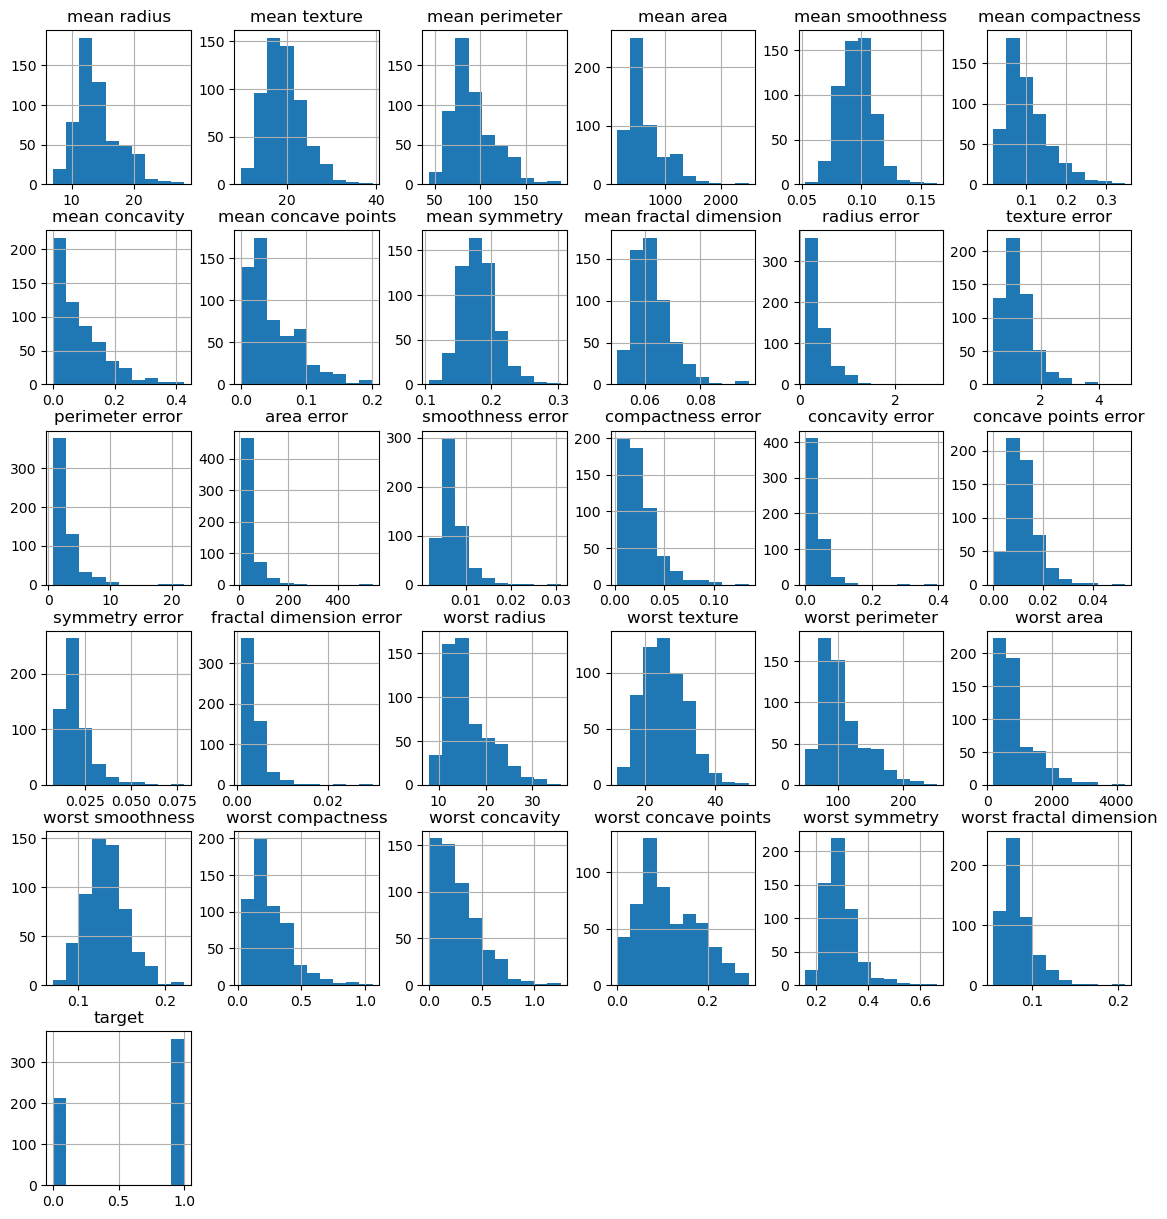

In [11]:
# Feature Distribution+
df.hist(figsize=(14,15))
plt.show()

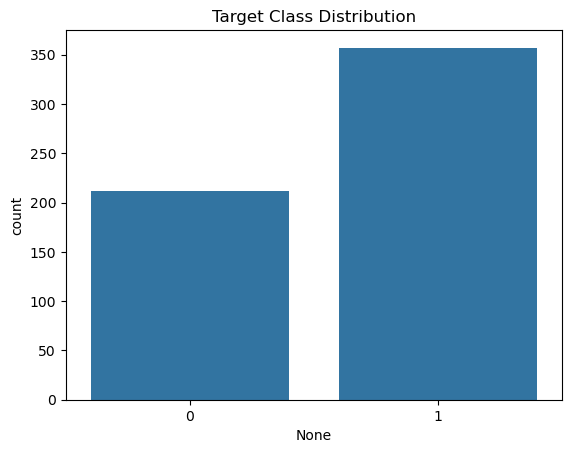

In [12]:
# Target Distribution
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()

**Data Preprocessing**

In [13]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

**Feature Engineering**

In [14]:
corr_matrix = X.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

drop_cols = [column for column in upper.columns if any(upper[column] > 0.95)]

X_reduced = X.drop(columns=drop_cols)

print("Removed features:", drop_cols)

Removed features: ['mean perimeter', 'mean area', 'perimeter error', 'area error', 'worst radius', 'worst perimeter', 'worst area']


**Train-Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reduced,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

**Machine Learning Pipeline**

In [16]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True))
])

**Model Training**

In [17]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('svc', SVC(probability=True))])

In [18]:
y_pred = pipeline.predict(X_test)

**Hyperparameter Tuning with GridSearchCV**

In [19]:
param_grid = {
    "svc__C": [0.1, 1, 10],
    "svc__kernel": ["linear", "rbf"],
    "svc__gamma": ["scale", "auto"]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svc', SVC(probability=True))]),
             n_jobs=-1,
             param_grid={'svc__C': [0.1, 1, 10],
                         'svc__gamma': ['scale', 'auto'],
                         'svc__kernel': ['linear', 'rbf']},
             scoring='accuracy')

In [20]:
# Best Parameters
print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'svc__C': 10, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}
Best CV Score: 0.9714285714285715


In [21]:
best_model = grid.best_estimator_

**Model Evaluation**

In [22]:
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:,1]

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.956140350877193
Precision: 0.9855072463768116
Recall: 0.9444444444444444
F1 Score: 0.9645390070921985
ROC-AUC: 0.994378306878307


In [24]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94        42
           1       0.99      0.94      0.96        72

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



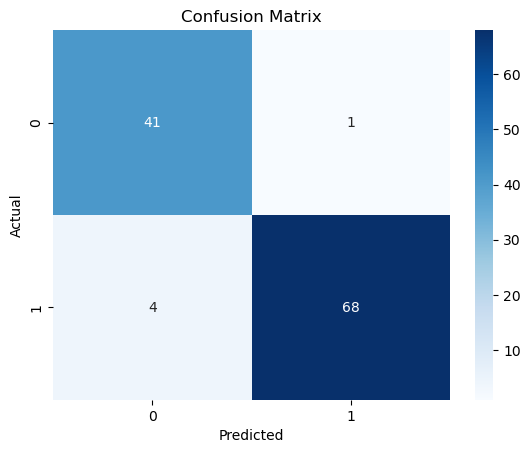

In [25]:
# Classification Report

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

**ROC Curve**

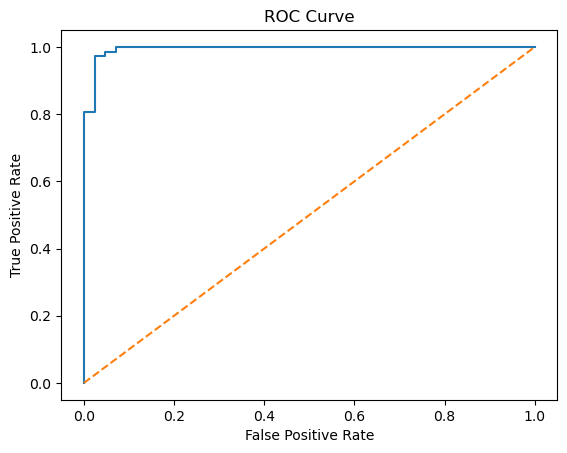

In [26]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],"--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

**Precision-Recall Curve**

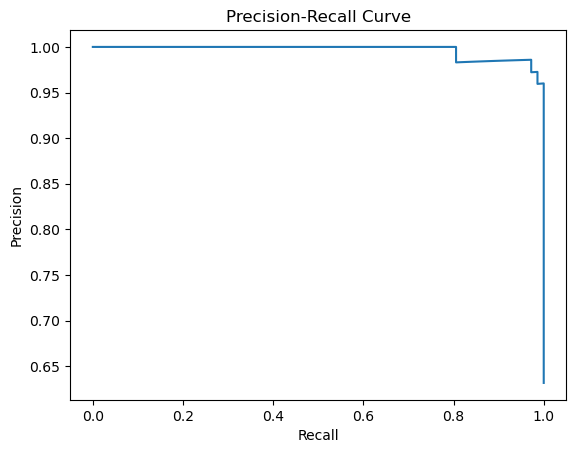

In [27]:
precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

**Feature Importance Visualization**

  0%|          | 0/50 [00:00<?, ?it/s]

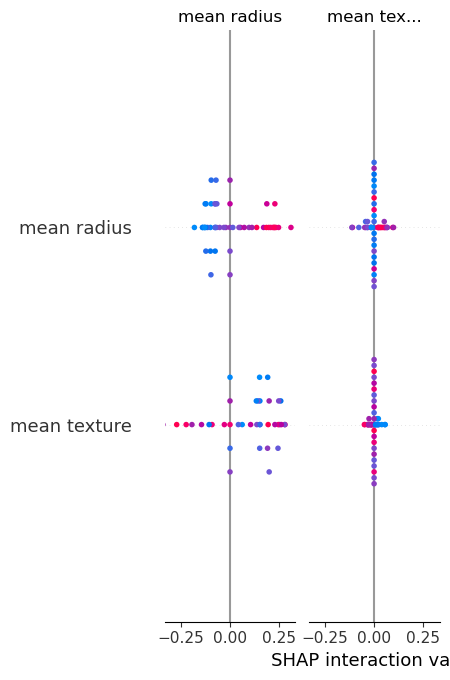

In [28]:
# Sample background data
background = shap.sample(X_train, 100)

# Prediction function
def model_predict(data):
    return best_model.predict_proba(pd.DataFrame(data, columns=X_train.columns))

# SHAP Kernel Explainer
explainer = shap.KernelExplainer(model_predict, background)

# Compute SHAP values
shap_values = explainer.shap_values(X_test.iloc[:50])

# Plot
shap.summary_plot(shap_values, X_test.iloc[:50])

**Saving the Model**

In [29]:
joblib.dump(best_model, "svc_model.pkl")

['svc_model.pkl']